# Problem 5 - K-Means Clustering

## Interview question

Implement K-Means clustering from scratch. Given `X: [N, D]` and number of clusters `K`, return cluster assignments and centroids.

## What is being asked

You need to implement the two repeated steps of K-Means: assign points to nearest centroids and recompute centroids. The interviewer also expects edge-case handling, especially empty clusters.

## Clarifying questions

- How should centroids be initialized?
- How many iterations should I run?
- What should I do with empty clusters?
- Should I stop when centroids converge?

## Solution

/tmp/ipykernel_3013394/2867313555.py:65: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X[k*cluster_size: (k+1)*cluster_size] = np.random.multivariate_normal(init_gt_c[k], np.random.rand(2, 2), cluster_size)


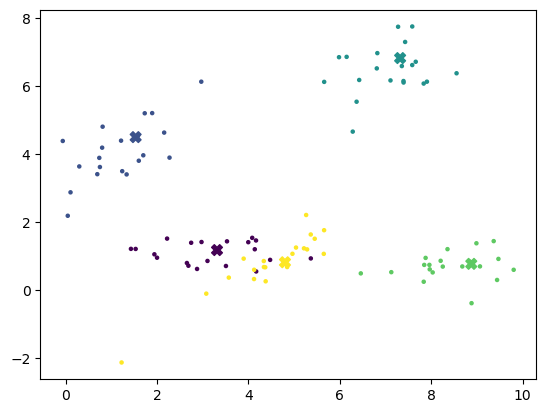

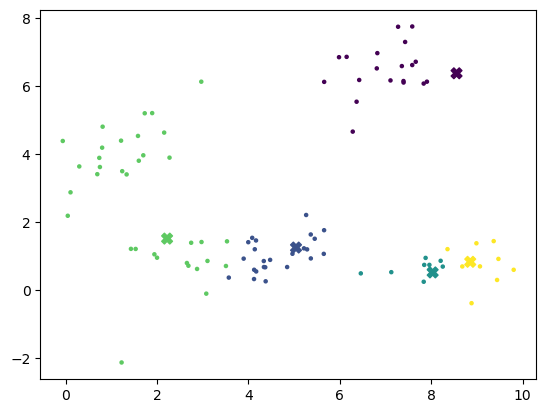

In [2]:
import numpy as np
import torch as th
import matplotlib.pyplot as plt


"""
Inputs X (NxD), K (int)
Outputs A (N), C (KxD)
"""

def l2_dist(X, C):
    # X = N x D
    # C = K x D

    # (a-b)^2 = a^2 + b^2 - 2ab

    X2 = np.sum(X**2, 1, keepdims=True) # N x 1
    C2 = np.sum(C**2, 1, keepdims=True) # K x 1

    dist = np.sqrt(np.maximum(X2 + C2.T - 2*X@C.T, 0))
    return dist

def kmeans_clustering(X, K, max_steps=1000, tol=1e-6):
    N, D = X.shape[0], X.shape[1]

    A = np.zeros(N)
    dim_min = np.min(X, 0, keepdims=True)
    dim_max = np.max(X, 0, keepdims=True)

    # C = np.random.rand(K, D) * (dim_max-dim_min) + dim_min
    C = X[np.random.choice(np.arange(N), K, False)]
    
    for _ in range(max_steps):
        dist = l2_dist(X, C) # N x K
        A = np.argmin(dist, 1)

        C_n = np.zeros((K, D))

        for c in range(K):
            if np.any(A == c):
                C_n[c] = np.mean(X[A==c], 0)
            else: 
                C_n[c] = C[c]

        shift = np.linalg.norm(C - C_n, 2)
        if shift<tol:
            break    

    return A, C
            


if __name__ == "__main__":
    # Example
    N = 100
    D = 2
    K = 5

    init_gt_c = np.random.rand(K, D)*10
    X = np.zeros((N, D))
    cluster_size = N//K
    init_C = np.zeros(N)

    for k in range(K):
        X[k*cluster_size: (k+1)*cluster_size] = np.random.multivariate_normal(init_gt_c[k], np.random.rand(2, 2), cluster_size)
        init_C[k*cluster_size: (k+1)*cluster_size] = k

    A, C = kmeans_clustering(X, K)

    plt.scatter(X[:, 0], X[:, 1], c=init_C, s=5)
    plt.scatter(init_gt_c[:, 0], init_gt_c[:, 1], c=np.arange(K), s=60, marker='X')
    plt.show()

    plt.scatter(X[:, 0], X[:, 1], c=A, s=5)
    plt.scatter(C[:, 0], C[:, 1], c=np.arange(K), s=60, marker='X')
    plt.show()


